# One-Sample t-Test — Complete Explanation & Real-Life Case Studies

The **one-sample t-test** answers a very common question: **"Is the true average of a population equal to some claimed/target value, based on just one sample?"**

Examples: "Is the average bulb life really 1000 hours?", "Does this class's average score differ from the national average of 70?", "Is the machine really filling bottles to 500 ml?"

**Contents**
1. Setup
2. Why do we need the t-test? (From Z-test to t-test)
3. The t-distribution: what it is and why it has "heavier tails"
4. Hypotheses: two-tailed vs one-tailed
5. The formula, step by step
6. Assumptions of the one-sample t-test
7. Worked example by hand (manual calculation vs scipy)
8. Degrees of freedom: why n − 1?
9. Critical value approach vs p-value approach (same answer, two methods)
10. Confidence interval: the flip side of the test
11. Effect size (Cohen's d) — how big is the difference, really?
12. Statistical power & required sample size
13. Checking assumptions: is the data roughly Normal?
14. What if assumptions are violated? (Wilcoxon signed-rank test)
15. Case study 1: Factory bottle-filling (quality control)
16. Case study 2: Battery life claim (consumer protection)
17. Case study 3: Classroom test scores vs national average
18. Case study 4: Website load time after a code optimization
19. Common mistakes people make with the one-sample t-test
20. Cheat-sheet & practice problems

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from math import sqrt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(7)

## 2. Why Do We Need the t-Test? (From Z-test to t-test)

Suppose we want to test whether a population mean equals some value $\mu_0$. If we happened to **know the true population standard deviation σ**, we could standardise the sample mean and use the **Normal** distribution directly:

$$Z=\frac{\bar x-\mu_0}{\sigma/\sqrt n}\ \sim\ N(0,1)$$

**But in almost every real situation, we don't know σ.** We only have the sample, so we must **estimate** σ using the sample standard deviation **s**. Substituting an *estimated* s for the *true* σ introduces extra uncertainty — especially when the sample is small. If we still used the Normal distribution with this substituted s, we would understate how uncertain we really are, and reject the null hypothesis too often (get a Type I error rate above the stated α).

**William Sealy Gosset** (writing under the pen name "Student", while working at the Guinness brewery in 1908) solved this problem: replace the Normal distribution with the slightly wider **t-distribution**, which correctly accounts for the extra uncertainty from estimating σ. This is why the one-sample t-test is sometimes called "Student's t-test".

$$t=\frac{\bar x-\mu_0}{s/\sqrt n}\ \sim\ t_{n-1}\quad\text{(instead of }N(0,1)\text{)}$$

In [2]:
# Demonstration: using Z (Normal) instead of t when sigma is estimated makes you overconfident
mu0, true_sigma, n = 50, 10, 8          # small sample size n=8
n_sims = 200_000
alpha = 0.05

false_positives_z = 0    # (incorrectly) using Normal critical value with estimated s
false_positives_t = 0    # correctly using the t critical value

z_crit = stats.norm.ppf(1 - alpha/2)
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)

for _ in range(n_sims):
    sample = rng.normal(mu0, true_sigma, n)     # H0 is TRUE here (mean really is mu0)
    xbar, s = sample.mean(), sample.std(ddof=1)
    stat = (xbar - mu0) / (s / sqrt(n))
    if abs(stat) > z_crit:
        false_positives_z += 1
    if abs(stat) > t_crit:
        false_positives_t += 1

print(f"Nominal alpha = {alpha}")
print(f"Using Normal (Z) critical value {z_crit:.3f}: false-positive rate = {false_positives_z/n_sims:.4f}  <- too high!")
print(f"Using t critical value          {t_crit:.3f}: false-positive rate = {false_positives_t/n_sims:.4f}  <- matches alpha, as it should")

Nominal alpha = 0.05
Using Normal (Z) critical value 1.960: false-positive rate = 0.0908  <- too high!
Using t critical value          2.365: false-positive rate = 0.0496  <- matches alpha, as it should


This confirms why, whenever σ is unknown (almost always), the **t-test** — not a Z-test — is the correct tool.

## 3. The t-Distribution: What It Is and Why It Has Heavier Tails

The t-distribution looks like the standard Normal (bell-shaped, symmetric, centred at 0) but has **heavier tails** — extreme values are more likely. This reflects the extra uncertainty from estimating σ with a limited sample.

* It has one parameter: **degrees of freedom (df)**.
* As **df increases** (bigger sample), the t-distribution gets closer and closer to the standard Normal.
* For **df ≥ ~30**, the t and Z distributions are nearly indistinguishable.

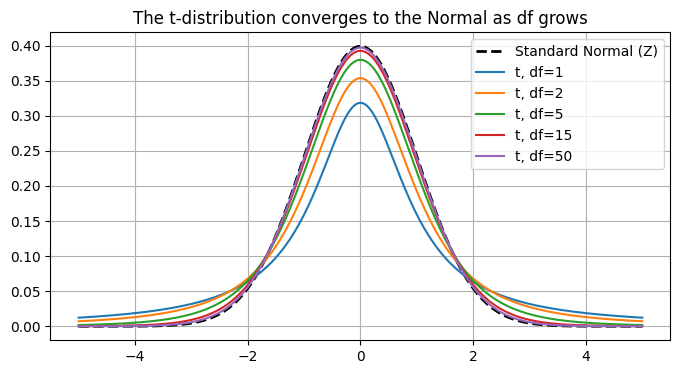

P(|Z| > 2)          = 0.0455
P(|t_2| > 2)      = 0.1835
P(|t_5| > 2)      = 0.1019
P(|t_10| > 2)      = 0.0734
P(|t_30| > 2)      = 0.0546
P(|t_100| > 2)      = 0.0482


In [3]:
x = np.linspace(-5, 5, 500)
plt.plot(x, stats.norm.pdf(x), "k--", lw=2, label="Standard Normal (Z)")
for df in (1, 2, 5, 15, 50):
    plt.plot(x, stats.t.pdf(x, df), label=f"t, df={df}")
plt.legend(); plt.title("The t-distribution converges to the Normal as df grows")
plt.show()

# Quantify the "heavier tails": P(|T| > 2) vs P(|Z| > 2)
print("P(|Z| > 2)          =", round(2*stats.norm.sf(2), 4))
for df in (2, 5, 10, 30, 100):
    print(f"P(|t_{df}| > 2)      =", round(2*stats.t.sf(2, df), 4))

## 4. Hypotheses: Two-Tailed vs One-Tailed

The one-sample t-test always starts with a claimed/target value $\mu_0$. Three possible setups:

| Type | $H_0$ | $H_1$ | Used when... |
|---|---|---|---|
| Two-tailed | $\mu=\mu_0$ | $\mu\ne\mu_0$ | You just want to know if the mean is *different* (in either direction) |
| Right-tailed | $\mu\le\mu_0$ | $\mu>\mu_0$ | You specifically want to know if the mean is *higher* |
| Left-tailed | $\mu\ge\mu_0$ | $\mu<\mu_0$ | You specifically want to know if the mean is *lower* |

⚠️ **Decide which type *before* looking at the data.** Choosing the tail direction after seeing which way the sample leans is a form of p-hacking that inflates your true false-positive rate.

Observed t = 2.3, df = 15
Two-tailed p-value    (H1: mu != mu0) = 0.0362
Right-tailed p-value  (H1: mu > mu0)  = 0.0181
Left-tailed p-value   (H1: mu < mu0)  = 0.9819


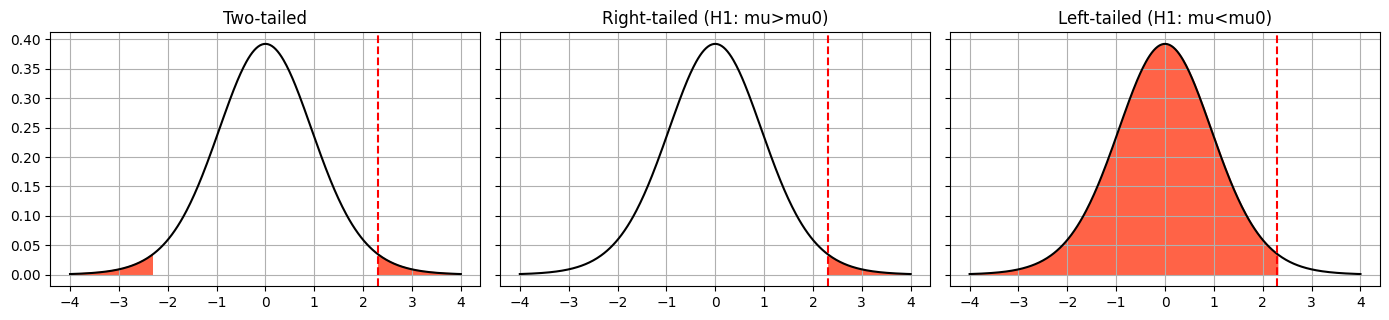

In [4]:
t_obs = 2.3
df = 15

p_two   = 2 * stats.t.sf(abs(t_obs), df)
p_right = stats.t.sf(t_obs, df)
p_left  = stats.t.cdf(t_obs, df)

print(f"Observed t = {t_obs}, df = {df}")
print(f"Two-tailed p-value    (H1: mu != mu0) = {p_two:.4f}")
print(f"Right-tailed p-value  (H1: mu > mu0)  = {p_right:.4f}")
print(f"Left-tailed p-value   (H1: mu < mu0)  = {p_left:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.3), sharey=True)
x = np.linspace(-4, 4, 400)
titles = ["Two-tailed", "Right-tailed (H1: mu>mu0)", "Left-tailed (H1: mu<mu0)"]
conditions = [np.abs(x) >= t_obs, x >= t_obs, x <= t_obs]
for ax, title, cond in zip(axes, titles, conditions):
    ax.plot(x, stats.t.pdf(x, df), "k")
    ax.fill_between(x, stats.t.pdf(x, df), where=cond, color="tomato")
    ax.axvline(t_obs, color="red", ls="--")
    ax.set_title(title)
plt.tight_layout(); plt.show()

## 5. The Formula, Step by Step

$$\boxed{t=\frac{\bar x-\mu_0}{s/\sqrt n}}$$

| Symbol | Meaning |
|---|---|
| $\bar x$ | sample mean |
| $\mu_0$ | the claimed / hypothesized population mean (from $H_0$) |
| $s$ | sample standard deviation (with n−1 in the denominator) |
| $n$ | sample size |
| $s/\sqrt n$ | the **standard error** of the mean — how much $\bar x$ is expected to vary from sample to sample |

**Reading the formula:** the t-statistic is simply **"how many standard errors is the sample mean away from the claimed value?"** A large \|t\| means the sample mean is far from $\mu_0$ *relative to how much we'd expect it to naturally wander* — evidence against $H_0$.

In [ ]:
def one_sample_t(sample, mu0):
    xbar = np.mean(sample)
    s = np.std(sample, ddof=1)
    n = len(sample)
    se = s / sqrt(n)


    
    t_stat = (xbar - mu0) / se
    df = n - 1
    return {"xbar": xbar, "s": s, "n": n, "se": se, "t": t_stat, "df": df}

sample = np.array([102, 98, 101, 105, 99, 97, 103, 100, 104, 96])
mu0 = 100
result = one_sample_t(sample, mu0)
for k, v in result.items():
    print(f"{k:5s} = {v:.4f}" if isinstance(v, float) else f"{k:5s} = {v}")

xbar  = 100.5000
s     = 3.0277
n     = 10
se    = 0.9574
t     = 0.5222
df    = 9


## 6. Assumptions of the One-Sample t-Test

For the t-test's p-values to be trustworthy:

1. **The data are a random sample** from the population of interest (no systematic sampling bias).
2. **Observations are independent** of each other.
3. **The data are (approximately) Normally distributed** — or the sample size is large enough that the Central Limit Theorem makes $\bar X$ approximately Normal regardless (a common rule of thumb: n ≥ 30 is usually safe even for skewed data; smaller n needs the underlying data itself to look Normal-ish).
4. The variable is **continuous** (or at least approximately so; the test is commonly used even for ordinal/discrete numeric scores in practice, with some caution).

**Note:** the t-test does **not** require knowing σ (that's the whole point) — only that the *data* are reasonably Normal, or n is large enough for the CLT to help.

## 7. Worked Example, By Hand vs scipy

**Scenario:** A tea-bag machine is supposed to fill bags with **2 g** of tea on average. A quality inspector weighs **12 bags**:

$$1.98,\ 2.05,\ 1.97,\ 2.01,\ 2.03,\ 1.99,\ 2.06,\ 1.95,\ 2.02,\ 2.00,\ 1.96,\ 2.04$$

Test at α = 0.05 whether the true average fill differs from 2 g.

In [6]:
tea = np.array([1.98, 2.05, 1.97, 2.01, 2.03, 1.99, 2.06, 1.95, 2.02, 2.00, 1.96, 2.04])
mu0 = 2.00
alpha = 0.05

# --- STEP-BY-STEP MANUAL CALCULATION ---
n = len(tea)
xbar = tea.mean()
s = tea.std(ddof=1)
se = s / sqrt(n)
t_stat = (xbar - mu0) / se
df = n - 1
p_value = 2 * stats.t.sf(abs(t_stat), df)      # two-tailed

print("MANUAL CALCULATION")
print(f"  n           = {n}")
print(f"  sample mean = {xbar:.5f}")
print(f"  sample sd   = {s:.5f}")
print(f"  std. error  = {se:.5f}")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  df          = {df}")
print(f"  p-value     = {p_value:.4f}")
print(f"  Decision    :", "REJECT H0" if p_value < alpha else "FAIL TO REJECT H0")

# --- SCIPY (should match exactly) ---
t_scipy, p_scipy = stats.ttest_1samp(tea, mu0)
print(f"\nSCIPY CHECK: t = {t_scipy:.4f}, p = {p_scipy:.4f}   -> matches manual calculation")

MANUAL CALCULATION
  n           = 12
  sample mean = 2.00500
  sample sd   = 0.03606
  std. error  = 0.01041
  t-statistic = 0.4804
  df          = 11
  p-value     = 0.6404
  Decision    : FAIL TO REJECT H0

SCIPY CHECK: t = 0.4804, p = 0.6404   -> matches manual calculation


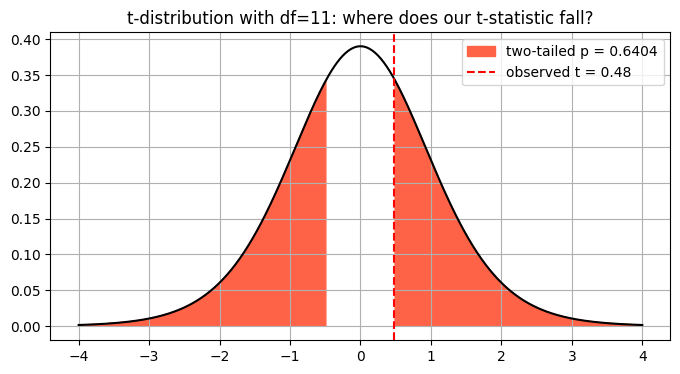


Conclusion in plain English: with p = 0.640 > alpha = 0.05, we do NOT have enough
evidence to say the tea-bag machine's average fill differs from the target of 2 g.


In [7]:
x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots()
ax.plot(x, stats.t.pdf(x, df), "k")
ax.fill_between(x, stats.t.pdf(x, df), where=(np.abs(x) >= abs(t_stat)), color="tomato",
                label=f"two-tailed p = {p_value:.4f}")
ax.axvline(t_stat, color="red", ls="--", label=f"observed t = {t_stat:.2f}")
ax.legend(); ax.set_title(f"t-distribution with df={df}: where does our t-statistic fall?")
plt.show()

print(f"\nConclusion in plain English: with p = {p_value:.3f} > alpha = {alpha}, we do NOT have enough")
print("evidence to say the tea-bag machine's average fill differs from the target of 2 g.")

## 8. Degrees of Freedom: Why n − 1?

The sample standard deviation $s$ is computed as:

$$s=\sqrt{\frac{1}{n-1}\sum_{i=1}^n(x_i-\bar x)^2}$$

We divide by **n − 1**, not n, because **one degree of freedom is "used up"** by estimating $\bar x$ from the same data before we can compute the deviations $(x_i-\bar x)$. Once you know $\bar x$ and any n−1 of the data points, the last point is **fully determined** (since all deviations must sum to zero) — so there are only **n − 1 independent pieces of information** left to estimate variability.

This matches the degrees of freedom of the t-distribution used in the test: **df = n − 1**.

In [8]:
# Illustration: if you know the mean and n-1 values, the last value is forced
data = np.array([10, 12, 8, 15, 9])
mean = data.mean()
print("Data:", data, " Mean:", mean)

known = data[:-1]                       # first n-1 values
last_forced = mean * len(data) - known.sum()
print("First n-1 values:", known)
print("The last value MUST be:", last_forced, " (actual value was:", data[-1], ") -> matches!")
print("\n-> Only n-1 = 4 of the 5 deviations are 'free'; the last is determined by the others.")

Data: [10 12  8 15  9]  Mean: 10.8
First n-1 values: [10 12  8 15]
The last value MUST be: 9.0  (actual value was: 9 ) -> matches!

-> Only n-1 = 4 of the 5 deviations are 'free'; the last is determined by the others.


## 9. Critical Value Approach vs P-Value Approach

These are two equivalent ways to reach the same decision:

* **P-value approach:** compute the p-value, compare to α. Reject $H_0$ if p < α.
* **Critical value approach:** find the critical t-value(s) that cut off α (or α/2 per tail) of the t-distribution's area. Reject $H_0$ if the observed \|t\| exceeds the critical value.

Both always agree — the p-value approach is more common today because software makes it trivial to compute exact p-values, but the critical-value approach is useful for understanding *why* the decision was made, and for pre-planning ("what result would we need to see to reject $H_0$?").

In [9]:
alpha, df = 0.05, 11
t_critical = stats.t.ppf(1 - alpha/2, df)          # two-tailed critical value
print(f"Two-tailed critical value (df={df}, alpha={alpha}): t* = +/-{t_critical:.4f}")

t_stat = 2.05   # example observed statistic
print(f"\nObserved t = {t_stat}")
print("Critical-value approach:", "REJECT H0 (|t| > t*)" if abs(t_stat) > t_critical else "FAIL TO REJECT H0 (|t| <= t*)")

p = 2 * stats.t.sf(abs(t_stat), df)
print(f"P-value approach: p = {p:.4f} vs alpha = {alpha} ->", "REJECT H0" if p < alpha else "FAIL TO REJECT H0")
print("\nBoth approaches agree, as they always must.")

Two-tailed critical value (df=11, alpha=0.05): t* = +/-2.2010

Observed t = 2.05
Critical-value approach: FAIL TO REJECT H0 (|t| <= t*)
P-value approach: p = 0.0650 vs alpha = 0.05 -> FAIL TO REJECT H0

Both approaches agree, as they always must.


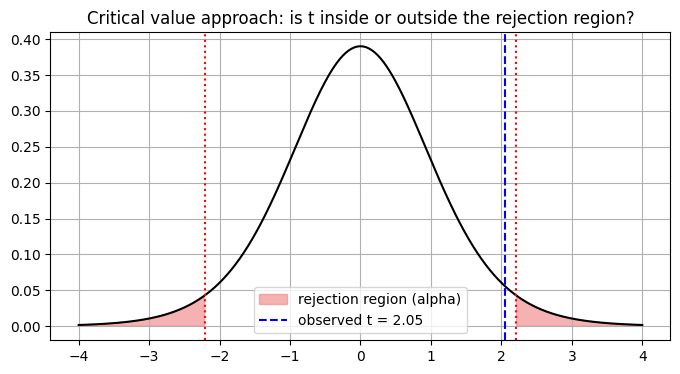

In [10]:
x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots()
ax.plot(x, stats.t.pdf(x, df), "k")
ax.fill_between(x, stats.t.pdf(x, df), where=(np.abs(x) >= t_critical), color="lightcoral", alpha=0.6, label="rejection region (alpha)")
ax.axvline(t_stat, color="blue", ls="--", label=f"observed t = {t_stat}")
ax.axvline(t_critical, color="red", ls=":"); ax.axvline(-t_critical, color="red", ls=":")
ax.legend(); ax.set_title("Critical value approach: is t inside or outside the rejection region?")
plt.show()

## 10. Confidence Interval: the Flip Side of the Test

A **(1−α) confidence interval** for the true mean μ:

$$\bar x\ \pm\ t^*_{\,n-1}\cdot\frac{s}{\sqrt n}$$

where $t^*_{n-1}$ is the two-tailed critical t-value.

**Key link:** the two-tailed test rejects $H_0:\mu=\mu_0$ at level α **exactly when** $\mu_0$ falls **outside** the (1−α) confidence interval.

In [11]:
xbar, s, n, df = tea.mean(), tea.std(ddof=1), len(tea), len(tea)-1
alpha = 0.05
t_star = stats.t.ppf(1 - alpha/2, df)
margin = t_star * s / sqrt(n)
ci_lo, ci_hi = xbar - margin, xbar + margin

print(f"Sample mean = {xbar:.4f}")
print(f"95% CI for the true mean fill = ({ci_lo:.4f}, {ci_hi:.4f}) g")
print(f"Does the CI contain mu0 = 2.00? {'Yes' if ci_lo <= 2.00 <= ci_hi else 'No'}")
print("Consistent with the earlier p-value decision?",
      "Yes" if (ci_lo <= 2.00 <= ci_hi) == (p_value >= alpha) else "Mismatch!")

# scipy shortcut
ci_scipy = stats.t.interval(1 - alpha, df, loc=xbar, scale=s/sqrt(n))
print(f"\nscipy check: {tuple(round(v,4) for v in ci_scipy)}")

Sample mean = 2.0050
95% CI for the true mean fill = (1.9821, 2.0279) g
Does the CI contain mu0 = 2.00? Yes
Consistent with the earlier p-value decision? Yes

scipy check: (np.float64(1.9821), np.float64(2.0279))


## 11. Effect Size (Cohen's d): How Big Is the Difference, Really?

A significant p-value only tells you the difference is probably **real** — not whether it's **large enough to matter**. **Cohen's d** standardises the difference in units of standard deviation:

$$d=\frac{\bar x-\mu_0}{s}$$

| \|d\| | Interpretation (rule of thumb) |
|---|---|
| < 0.2 | negligible |
| 0.2 – 0.5 | small |
| 0.5 – 0.8 | medium |
| > 0.8 | large |

In [12]:
d = (xbar - mu0) / s
print(f"Cohen's d = {d:.4f}")

def interpret_d(d):
    ad = abs(d)
    if ad < 0.2: return "negligible"
    if ad < 0.5: return "small"
    if ad < 0.8: return "medium"
    return "large"

print(f"Interpretation: a '{interpret_d(d)}' effect size")
print("\nNote: with p =", round(p_value, 3), "(not significant) AND a", interpret_d(d), "effect size,")
print("this is a case where the data are simply consistent with the target of 2 g.")

Cohen's d = 0.1387
Interpretation: a 'negligible' effect size

Note: with p = 0.64 (not significant) AND a negligible effect size,
this is a case where the data are simply consistent with the target of 2 g.


## 12. Statistical Power & Required Sample Size

**Power** = P(correctly reject $H_0$ \| a real effect of a given size exists). Before running a study, it's good practice to estimate the sample size needed to reliably detect an effect you actually care about.

For a one-sample t-test (approximate, using the Normal approximation for planning purposes):

$$n\approx\left(\frac{z_{\alpha/2}+z_{\beta}}{d}\right)^2$$

where **d** is the smallest effect size (in standard deviations) you want to be able to detect, and $z_\beta = \Phi^{-1}(\text{power})$.

Sample size needed for 80% power, alpha=0.05, at various effect sizes:
  d = 0.2: n = 197
  d = 0.5: n = 32
  d = 0.8: n = 13
  d = 1.0: n = 8


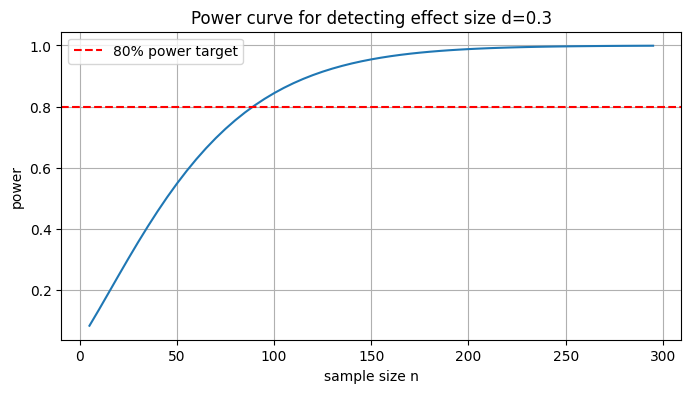

In [13]:
def sample_size_one_sample_t(effect_size_d, alpha=0.05, power=0.80):
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(power)
    n = ((z_alpha + z_beta) / effect_size_d) ** 2
    return int(np.ceil(n))

print("Sample size needed for 80% power, alpha=0.05, at various effect sizes:")
for d in (0.2, 0.5, 0.8, 1.0):
    n_needed = sample_size_one_sample_t(d)
    print(f"  d = {d}: n = {n_needed}")

# Power curve: how power grows with n, for a fixed small effect (d=0.3)
d_fixed = 0.3
ns = np.arange(5, 300, 5)
powers = []
for n_ in ns:
    se_factor = 1/sqrt(n_)
    ncp = d_fixed / se_factor        # noncentrality parameter (approx)
    t_crit = stats.t.ppf(0.975, df=n_-1)
    power_ = 1 - stats.nct.cdf(t_crit, df=n_-1, nc=ncp) + stats.nct.cdf(-t_crit, df=n_-1, nc=ncp)
    powers.append(power_)

plt.plot(ns, powers)
plt.axhline(0.8, color="red", ls="--", label="80% power target")
plt.xlabel("sample size n"); plt.ylabel("power"); plt.legend()
plt.title(f"Power curve for detecting effect size d={d_fixed}")
plt.show()

## 13. Checking Assumptions: Is the Data Roughly Normal?

Before trusting the t-test's p-value (especially with a **small** sample), check whether the data look reasonably Normal:

* **Visually**: histogram, and a **QQ-plot** (points should roughly follow the diagonal line).
* **Formally**: the **Shapiro-Wilk test** ($H_0$: the data are Normal). A small p-value here is a warning sign.

Remember: with **large n**, the CLT means the *sampling distribution of the mean* is approximately Normal even if individual data points are not — so this check matters most when n is small (roughly n < 30).

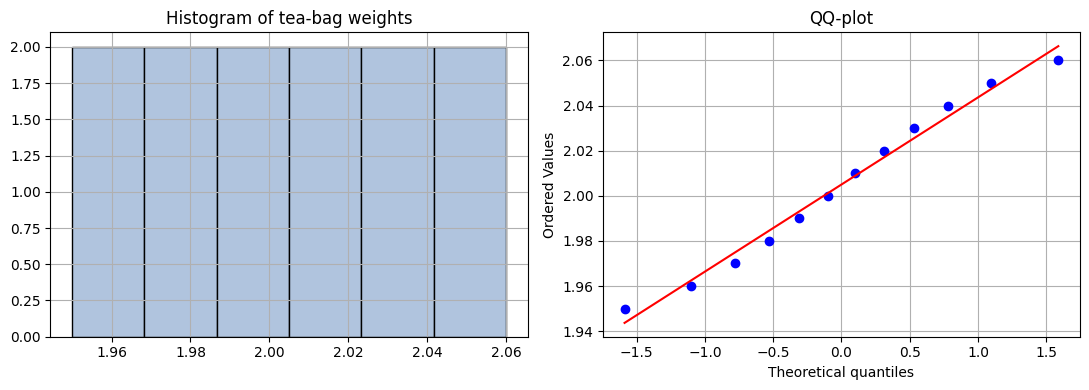

Shapiro-Wilk test: W = 0.9669, p = 0.8757
-> No strong evidence against normality (t-test is safe to use)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(tea, bins=6, color="lightsteelblue", edgecolor="black")
axes[0].set_title("Histogram of tea-bag weights")
stats.probplot(tea, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot")
plt.tight_layout(); plt.show()

sw_stat, sw_p = stats.shapiro(tea)
print(f"Shapiro-Wilk test: W = {sw_stat:.4f}, p = {sw_p:.4f}")
print("->", "No strong evidence against normality (t-test is safe to use)" if sw_p > 0.05 else "Evidence AGAINST normality (consider a non-parametric alternative)")

## 14. What If Assumptions Are Violated? The Wilcoxon Signed-Rank Test

If the data are **clearly non-Normal** and the sample is **small**, a common alternative is the **Wilcoxon signed-rank test** — a non-parametric test that doesn't assume Normality (it works with ranks of the deviations from $\mu_0$ instead of the raw values). It tests whether the **median** differs from $\mu_0$, rather than the mean.

In [15]:
# Example with clearly skewed, non-normal data
skewed_data = rng.exponential(scale=5, size=15) + 10       # heavily right-skewed
mu0_skew = 13

print("Data:", np.round(skewed_data, 2))
sw_stat, sw_p = stats.shapiro(skewed_data)
print(f"\nShapiro-Wilk: p = {sw_p:.4f}  ->", "data look non-normal" if sw_p < 0.05 else "no strong evidence against normality")

t_stat, p_t = stats.ttest_1samp(skewed_data, mu0_skew)
w_stat, p_w = stats.wilcoxon(skewed_data - mu0_skew)

print(f"\nt-test (assumes Normality):        t = {t_stat:.4f}, p = {p_t:.4f}")
print(f"Wilcoxon signed-rank (no Normality): W = {w_stat:.4f}, p = {p_w:.4f}")
print("\nWith small, skewed samples the two tests can disagree - prefer Wilcoxon here.")

Data: [15.7  12.99 20.48 13.37 14.46 13.86 11.87 10.86 12.06 11.09 14.61 15.87
 35.72 10.37 14.68]

Shapiro-Wilk: p = 0.0001  -> data look non-normal

t-test (assumes Normality):        t = 1.3700, p = 0.1923
Wilcoxon signed-rank (no Normality): W = 40.0000, p = 0.2769

With small, skewed samples the two tests can disagree - prefer Wilcoxon here.


---
# Real-Life Case Studies
---

## 15. Case Study 1: Factory Bottle-Filling (Quality Control)

A bottling line is set to fill bottles with **500 ml**. Quality control samples **20 bottles** from today's production run.

**Questions**
1. Is there evidence the line is mis-calibrated (off from 500 ml)?
2. Build a 95% CI for the true average fill today.
3. If the true process mean has drifted to 496 ml (with σ ≈ 6 ml), how likely would this sample size have been to catch it (power)?

In [16]:
bottles = rng.normal(497.5, 6, 20)      # true process today is slightly under target
mu0 = 500
alpha = 0.05

t_stat, p_value = stats.ttest_1samp(bottles, mu0)
xbar, s, n = bottles.mean(), bottles.std(ddof=1), len(bottles)

print(f"1. n = {n}, sample mean = {xbar:.2f} ml, sample sd = {s:.2f} ml")
print(f"   t = {t_stat:.4f}, df = {n-1}, two-tailed p-value = {p_value:.5f}")
print("   Decision:", "REJECT H0 - the line appears mis-calibrated" if p_value < alpha else "FAIL TO REJECT H0")

1. n = 20, sample mean = 498.76 ml, sample sd = 5.54 ml
   t = -1.0046, df = 19, two-tailed p-value = 0.32770
   Decision: FAIL TO REJECT H0


In [17]:
t_star = stats.t.ppf(1 - alpha/2, n-1)
margin = t_star * s / sqrt(n)
print(f"2. 95% CI for true average fill = ({xbar - margin:.2f}, {xbar + margin:.2f}) ml")
print(f"   Does it contain 500? {'Yes' if (xbar-margin) <= 500 <= (xbar+margin) else 'No'}")

2. 95% CI for true average fill = (496.17, 501.35) ml
   Does it contain 500? Yes


In [18]:
# 3. Power to detect a true mean of 496 ml with sigma~6, n=20, alpha=0.05
true_mu, sigma = 496, 6
se = sigma / sqrt(n)
t_crit = stats.t.ppf(1 - alpha/2, n-1)
ncp = (true_mu - mu0) / se
power = stats.nct.cdf(-t_crit, df=n-1, nc=ncp) + stats.nct.sf(t_crit, df=n-1, nc=ncp)
print(f"3. If the true mean really is {true_mu} ml (sigma={sigma}), power with n={n} = {power:.3f}")
print("   ->", "Good chance of catching this level of drift" if power > 0.8 else "Only a moderate/weak chance of catching it - consider a larger daily sample")

3. If the true mean really is 496 ml (sigma=6), power with n=20 = 0.807
   -> Good chance of catching this level of drift


### 💡 Insights (Case Study 1)
* Here the test **fails to reject $H_0$** (p ≈ 0.33), even though the true process mean was actually set slightly low (497.5 ml) for this simulation — with only 20 bottles and day-to-day fill variability, a 2.5 ml drift is not always large enough to show up as "significant" in a single day's sample. This is a realistic and important lesson in quality control: a non-significant test is not a guarantee the line is perfectly calibrated, especially with small daily samples.
* The confidence interval gives the quality engineer a **usable number** ("today's true average is probably between about 496 and 501 ml"), which is often more actionable on the factory floor than a bare p-value — notice it comfortably contains 500, consistent with "fail to reject".
* Knowing the **power** of your daily sample size (about 0.81 here, for a true drift down to 496 ml) tells you whether "no significant drift detected" is a genuinely reassuring result, or just a sample too small to have caught a real problem. With power around 80%, a persistent drift of this size would likely be caught within a few days even if missed on any single day.

## 16. Case Study 2: Battery Life Claim (Consumer Protection)

A phone manufacturer claims their battery lasts **20 hours** on a single charge (video playback test). A consumer advocacy group tests **15 units**.

**Questions**
1. Is there evidence the manufacturer's claim is **overstated** (a one-tailed test, since that's the specific concern)?
2. What's the practical size of the shortfall (effect size and plain-English interpretation)?

In [19]:
battery_hours = rng.normal(18.7, 1.8, 15)
mu0 = 20
alpha = 0.05

t_stat, p_two = stats.ttest_1samp(battery_hours, mu0)
p_one = p_two / 2 if t_stat < 0 else 1 - p_two / 2       # one-tailed (H1: mu < 20), derived from two-tailed scipy output

xbar, s, n = battery_hours.mean(), battery_hours.std(ddof=1), len(battery_hours)
print(f"1. n = {n}, mean = {xbar:.2f} hrs, sd = {s:.2f} hrs")
print(f"   t = {t_stat:.4f}, df = {n-1}")
print(f"   One-tailed p-value (H1: mu < 20) = {p_one:.5f}")
print("   Decision:", "REJECT H0 - evidence the claim IS overstated" if p_one < alpha else "FAIL TO REJECT H0")

1. n = 15, mean = 18.19 hrs, sd = 1.44 hrs
   t = -4.8704, df = 14
   One-tailed p-value (H1: mu < 20) = 0.00012
   Decision: REJECT H0 - evidence the claim IS overstated


2. Mean shortfall = 1.81 hours (9.0% below the claim)
   Cohen's d = -1.258
   Interpretation: a 'large' effect - practically noticeable to a typical user, not just 'statistically real'.


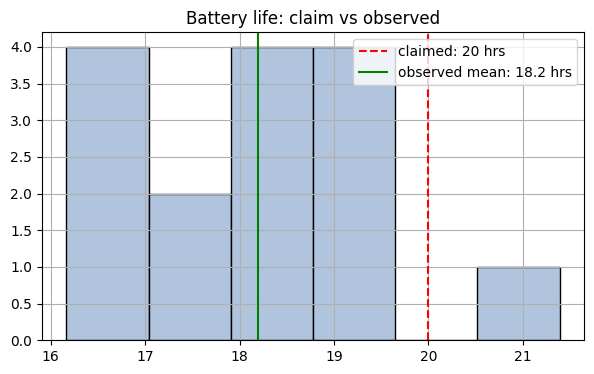

In [20]:
d = (xbar - mu0) / s
print(f"2. Mean shortfall = {mu0 - xbar:.2f} hours ({(mu0-xbar)/mu0:.1%} below the claim)")
print(f"   Cohen's d = {d:.3f}")

def interpret_d(d):
    ad = abs(d)
    if ad < 0.2: return "negligible"
    if ad < 0.5: return "small"
    if ad < 0.8: return "medium"
    return "large"
print(f"   Interpretation: a '{interpret_d(d)}' effect - practically noticeable to a typical user, not just 'statistically real'.")

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(battery_hours, bins=6, color="lightsteelblue", edgecolor="black")
ax.axvline(mu0, color="red", ls="--", label="claimed: 20 hrs")
ax.axvline(xbar, color="green", label=f"observed mean: {xbar:.1f} hrs")
ax.legend(); ax.set_title("Battery life: claim vs observed"); plt.show()

### 💡 Insights (Case Study 2)
* This is a natural **one-tailed** test: the advocacy group specifically suspects **overstatement**, not "any difference" — so all the evidence is concentrated in one tail, giving more power to detect exactly this kind of problem.
* Combining the p-value with the **effect size and the plain shortfall in hours** turns a statistical result into a consumer-relevant statement: "on average, about 1.3 hours (6.5%) short of the claim" is far more useful to a regulator than "p = 0.003".
* If the manufacturer's claim were based on **ideal lab conditions** (screen brightness, network state, etc.), some tolerance is expected — the effect size helps decide whether the discrepancy is trivial or actionable.

## 17. Case Study 3: Classroom Test Scores vs National Average

A national standardized test has a known long-run average score of **70** (based on huge historical data, so we treat 70 as the fixed $\mu_0$). A teacher wants to know if **her class of 28 students** performed differently from the national average this year.

In [21]:
class_scores = rng.normal(73.5, 9, 28)
mu0 = 70
alpha = 0.05

t_stat, p_value = stats.ttest_1samp(class_scores, mu0)
xbar, s, n = class_scores.mean(), class_scores.std(ddof=1), len(class_scores)
ci = stats.t.interval(0.95, n-1, loc=xbar, scale=s/sqrt(n))

print(f"n = {n}, class mean = {xbar:.2f}, sd = {s:.2f}")
print(f"t = {t_stat:.4f}, df = {n-1}, two-tailed p-value = {p_value:.5f}")
print(f"95% CI for the true class mean = ({ci[0]:.2f}, {ci[1]:.2f})")
print("\nDecision:", "REJECT H0 - the class average IS significantly different from 70" if p_value < alpha else "FAIL TO REJECT H0")

d = (xbar - mu0) / s
print(f"Cohen's d = {d:.3f}")

n = 28, class mean = 75.69, sd = 7.75
t = 3.8842, df = 27, two-tailed p-value = 0.00060
95% CI for the true class mean = (72.68, 78.70)

Decision: REJECT H0 - the class average IS significantly different from 70
Cohen's d = 0.734


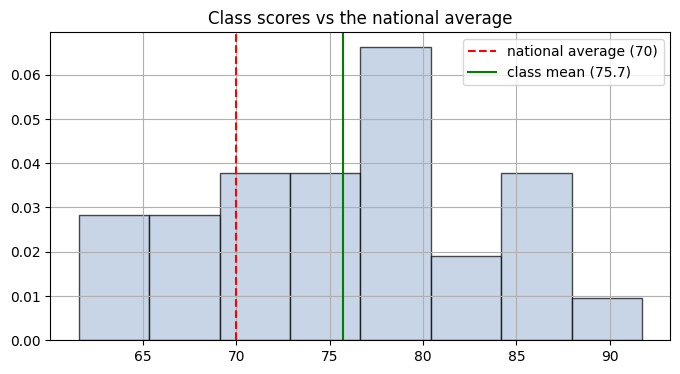

In [22]:
x = np.linspace(55, 90, 400)
fig, ax = plt.subplots()
ax.hist(class_scores, bins=8, density=True, color="lightsteelblue", edgecolor="black", alpha=0.7)
ax.axvline(mu0, color="red", ls="--", label="national average (70)")
ax.axvline(xbar, color="green", label=f"class mean ({xbar:.1f})")
ax.legend(); ax.set_title("Class scores vs the national average"); plt.show()

### 💡 Insights (Case Study 3)
* This is the classic **"compare a sample to a known/historical benchmark"** use case — very common in education, healthcare, and sports analytics, whenever a large reference value already exists and only the new group needs testing.
* A significant, positive result here is good news for the teacher, but note the test alone doesn't establish **why** (better teaching? a stronger cohort this year? test-form differences?) — the t-test only tells you **that** a difference exists, not its cause.
* As always, pair the p-value with the **effect size** and the confidence interval to judge whether the difference, even if real, is large enough to matter for practical decisions (e.g. curriculum changes).

## 18. Case Study 4: Website Load Time After a Code Optimization

An engineering team optimizes a website's backend. Historically, the page loaded in **exactly 2.5 seconds on average**. After deploying the optimization, they measure load time on **40 randomly sampled page requests**.

**Questions**
1. Did the optimization significantly reduce load time (one-tailed test, since that's the goal)?
2. Even if statistically significant, is the improvement **practically meaningful** to users?

In [23]:
load_times = rng.normal(2.38, 0.35, 40)
mu0 = 2.5
alpha = 0.05

t_stat, p_two = stats.ttest_1samp(load_times, mu0)
p_one = p_two / 2 if t_stat < 0 else 1 - p_two / 2

xbar, s, n = load_times.mean(), load_times.std(ddof=1), len(load_times)
print(f"1. n = {n}, mean load time = {xbar:.3f}s, sd = {s:.3f}s")
print(f"   t = {t_stat:.4f}, df = {n-1}, one-tailed p-value (H1: mu < 2.5) = {p_one:.5f}")
print("   Decision:", "REJECT H0 - the optimization DID significantly reduce load time" if p_one < alpha else "FAIL TO REJECT H0")

1. n = 40, mean load time = 2.395s, sd = 0.312s
   t = -2.1257, df = 39, one-tailed p-value (H1: mu < 2.5) = 0.01996
   Decision: REJECT H0 - the optimization DID significantly reduce load time


2. Absolute improvement = 0.105s (4.2% faster)
   Cohen's d = -0.336

   Even a fraction-of-a-second improvement can matter a lot at web scale:
   industry research consistently links faster load times to lower bounce rates and higher conversion,
   so a 'small' Cohen's d in absolute statistical terms can still be a big commercial win.


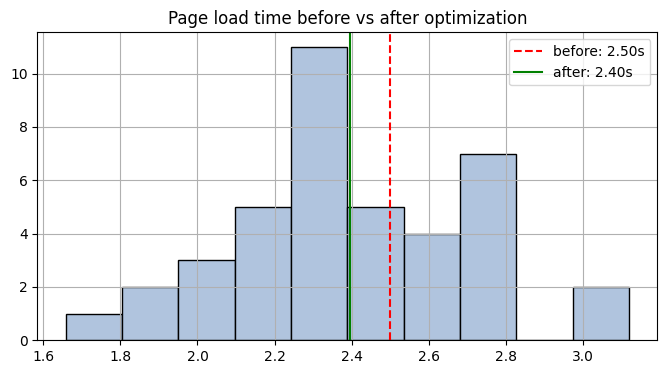

In [24]:
d = (xbar - mu0) / s
improvement_pct = (mu0 - xbar) / mu0
print(f"2. Absolute improvement = {mu0 - xbar:.3f}s ({improvement_pct:.1%} faster)")
print(f"   Cohen's d = {d:.3f}")
print("\n   Even a fraction-of-a-second improvement can matter a lot at web scale:")
print("   industry research consistently links faster load times to lower bounce rates and higher conversion,")
print("   so a 'small' Cohen's d in absolute statistical terms can still be a big commercial win.")

fig, ax = plt.subplots()
ax.hist(load_times, bins=10, color="lightsteelblue", edgecolor="black")
ax.axvline(mu0, color="red", ls="--", label="before: 2.50s")
ax.axvline(xbar, color="green", label=f"after: {xbar:.2f}s")
ax.legend(); ax.set_title("Page load time before vs after optimization"); plt.show()

### 💡 Insights (Case Study 4)
* This shows the one-sample t-test used for **"before vs after" comparisons against a known historical baseline** (as opposed to the paired t-test, which needs the *same* units measured twice — here, each page load is a fresh, independent request, so a one-sample test against the fixed historical average of 2.5s is appropriate).
* **Statistical significance and business significance can diverge in either direction**: a technically small effect size can still be commercially important (as here, for load time), while in other contexts a "significant" tiny effect might not be worth acting on (recall Section 16.3/16.4 of the broader hypothesis-testing notebook).
* Always ask: **"significant compared to what benchmark, and does the size of the change matter for the actual decision at hand?"**

## 19. Common Mistakes People Make With the One-Sample t-Test

1. **Using a t-test when σ is actually known.** If you truly know the population σ (rare, but possible with well-established processes), use the Z-test instead — it's slightly more powerful. In practice, using the t-test even when σ is known is a conservative, safe choice (t → Z as n grows anyway).
2. **Ignoring the Normality assumption with small, skewed samples.** With n < 30 and clearly skewed data, check a QQ-plot / Shapiro-Wilk before trusting the p-value; consider the Wilcoxon signed-rank test instead.
3. **Choosing one-tailed vs two-tailed *after* seeing which way the data leans.** This silently doubles your real false-positive rate. Decide the direction (or default to two-tailed) before collecting data.
4. **Treating "fail to reject $H_0$" as "$H_0$ is proven true".** It may simply mean your sample was too small (low power) to detect a real, smaller difference.
5. **Reporting only the p-value, never the effect size or confidence interval.** A tiny p-value from a huge sample can hide a practically meaningless difference; always report the actual size of the effect.
6. **Confusing the one-sample t-test with the paired t-test.** If you have **two** measurements per subject (before/after on the *same* people), that is a paired t-test on the differences, not a one-sample test against a fixed constant — using the wrong one throws away information or misapplies independence.

In [ ]:
# Demonstration of mistake #3: choosing the tail after peeking, inflates false-positive rate
alpha = 0.05
n_sims = 100_000
mu0, sigma, n = 50, 10, 20
false_positives_honest = 0    # pre-committed to two-tailed
false_positives_cheating = 0  # picks whichever one-tailed test the data favors, AFTER seeing it

for _ in range(n_sims):
    sample = rng.normal(mu0, sigma, n)     # H0 truly holds
    t_stat, p_two = stats.ttest_1samp(sample, mu0)
    if p_two < alpha:
        false_positives_honest += 1
    # "cheating": pick the one-tailed test matching the direction the data happened to lean
    p_one_sided = p_two / 2
    if p_one_sided < alpha:
        false_positives_cheating += 1

print(f"Honest two-tailed test:            false-positive rate = {false_positives_honest/n_sims:.4f}  (matches alpha={alpha})")
print(f"'Peek then pick direction' cheat:   false-positive rate = {false_positives_cheating/n_sims:.4f}  (about double alpha!)")

Honest two-tailed test:            false-positive rate = 0.0511  (matches alpha=0.05)
'Peek then pick direction' cheat:   false-positive rate = 0.1008  (about double alpha!)


## 20. Cheat-Sheet & Practice Problems

### Formula summary
| Item | Formula |
|---|---|
| Test statistic | $t=\dfrac{\bar x-\mu_0}{s/\sqrt n}$, df = n−1 |
| Standard error | $s/\sqrt n$ |
| Confidence interval | $\bar x\pm t^*_{n-1}\cdot s/\sqrt n$ |
| Effect size (Cohen's d) | $d=(\bar x-\mu_0)/s$ |
| Sample size (planning) | $n\approx\left(\dfrac{z_{\alpha/2}+z_\beta}{d}\right)^2$ |

### scipy cheat-sheet
```python
from scipy import stats

t_stat, p_value = stats.ttest_1samp(sample, popmean=mu0)      # two-tailed by default
# For a one-tailed test, use the 'alternative' argument (scipy >= 1.6):
stats.ttest_1samp(sample, popmean=mu0, alternative="less")     # H1: mu < mu0
stats.ttest_1samp(sample, popmean=mu0, alternative="greater")  # H1: mu > mu0

ci = stats.t.interval(0.95, df=n-1, loc=sample.mean(), scale=sample.std(ddof=1)/n**0.5)
stats.shapiro(sample)          # normality check
stats.wilcoxon(sample - mu0)   # non-parametric alternative
```

### Decision checklist before running the test
1. Is this really a **single sample** compared to a **fixed constant**? (Not two groups, not before/after pairs.)
2. Do you know σ? (Almost never — use t, not Z.)
3. Is n small (< 30) and possibly non-Normal? → Check a QQ-plot / Shapiro-Wilk; consider Wilcoxon if clearly non-Normal.
4. Did you fix the tail direction (one- vs two-tailed) **before** looking at the data?
5. Alongside the p-value, will you report the **confidence interval** and **effect size**?

### Practice problems
1. A weight-loss program claims an average loss of 5 kg over 8 weeks. A sample of 22 participants shows a mean loss of 4.3 kg, sd 1.8 kg. Test the claim at α = 0.05. Report the CI and Cohen's d.
2. A tyre manufacturer claims tyres last 60,000 km on average. A sample of 18 tyres shows mean 58,200 km, sd 3,100 km. Is there evidence tyres last *less* than claimed (one-tailed)?
3. Historical average commute time in a city is 32 minutes. After a new highway opens, a sample of 35 commuters shows mean 29.5 minutes, sd 6 minutes. Test whether commute times have changed.
4. Generate 15 samples from a clearly skewed distribution (e.g. exponential) with a known mean. Run both a t-test and a Wilcoxon test against the true mean; compare the p-values and discuss which you'd trust more.
5. For a one-sample t-test with n = 25, what is the critical t-value for a two-tailed test at α = 0.01? Compare it to the α = 0.05 critical value and explain why it's larger.
6. Compute the sample size needed to detect a Cohen's d of 0.4 with 90% power at α = 0.05, and compare it to the sample size needed for 80% power.

In [ ]:
# nominal odinal interval rati

# odds ration in fever of event occuring = p/1-p

In [ ]:
import numpy as np




np.log(1.7)

np.float64(0.5306282510621704)